In [1]:
import numpy as np
import pandas as pd
# import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

## Load MNIST Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


## Display Sample Images


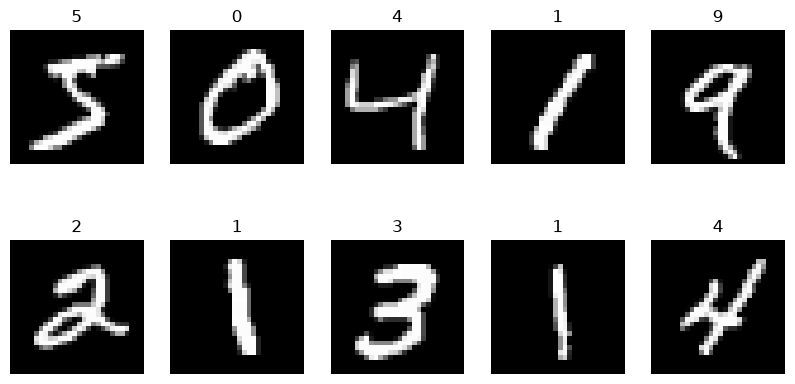

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()


## Normalize images

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## Flatten images

In [5]:
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape(10000,784)

print(X_train.shape)

(60000, 784)


In [7]:
# one hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## ReLU model

In [8]:
relu_model = Sequential()

relu_model.add(Dense(128, activation="relu", input_shape=(784,)))
relu_model.add(Dense(64, activation="relu"))
relu_model.add(Dense(10, activation="softmax"))

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
relu_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
# train relu
history_relu = relu_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9205 - loss: 0.2689 - val_accuracy: 0.9565 - val_loss: 0.1426
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9659 - loss: 0.1106 - val_accuracy: 0.9672 - val_loss: 0.1124
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9749 - loss: 0.0789 - val_accuracy: 0.9727 - val_loss: 0.0943
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9812 - loss: 0.0585 - val_accuracy: 0.9707 - val_loss: 0.0987
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9857 - loss: 0.0452 - val_accuracy: 0.9732 - val_loss: 0.1008
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9881 - loss: 0.0363 - val_accuracy: 0.9736 - val_loss: 0.1005
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9912 - loss: 0.0279 - val_accuracy: 0.9755 - val_loss: 0.0959
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9918 - loss: 0.0240 - 

## bulid sigmoid model

In [11]:
sigmoid_model = Sequential()

sigmoid_model.add(Dense(128, activation="sigmoid", input_shape=(784,)))
sigmoid_model.add(Dense(64, activation="sigmoid"))
sigmoid_model.add(Dense(10, activation="softmax"))

In [12]:
# compile 
sigmoid_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
# train 
history_sigmoid = sigmoid_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8685 - loss: 0.5239 - val_accuracy: 0.9310 - val_loss: 0.2368
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9407 - loss: 0.2007 - val_accuracy: 0.9523 - val_loss: 0.1677
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9576 - loss: 0.1417 - val_accuracy: 0.9600 - val_loss: 0.1361
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9685 - loss: 0.1066 - val_accuracy: 0.9678 - val_loss: 0.1122
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9750 - loss: 0.0843 - val_accuracy: 0.9700 - val_loss: 0.1017
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9805 - loss: 0.0665 - val_accuracy: 0.9717 - val_loss: 0.0943
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9849 - loss: 0.0526 - val_accuracy: 0.9732 - val_loss: 0.0910
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9881 - loss: 0.0430 - 

In [14]:
relu_loss, relu_accuracy = relu_model.evaluate(X_test, y_test)

print("ReLU Accuracy:", relu_accuracy)
print("ReLU Loss:", relu_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9755 - loss: 0.1006
ReLU Accuracy: 0.9754999876022339
ReLU Loss: 0.10058750212192535


In [15]:
sigmoid_loss, sigmoid_accuracy = sigmoid_model.evaluate(X_test, y_test)

print("Sigmoid Accuracy:", sigmoid_accuracy)
print("Sigmoid Loss:", sigmoid_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9755 - loss: 0.0804
Sigmoid Accuracy: 0.9754999876022339
Sigmoid Loss: 0.08037586510181427


## Plot Accuracy (ReLU)

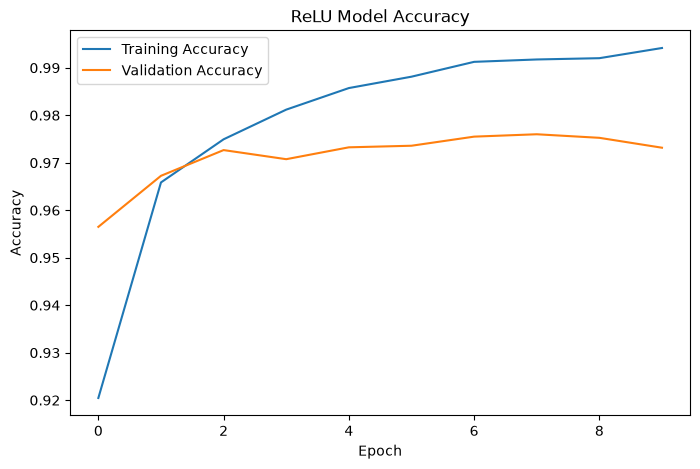

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history_relu.history["accuracy"], label="Training Accuracy")
plt.plot(history_relu.history["val_accuracy"], label="Validation Accuracy")

plt.title("ReLU Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Plot Loss (ReLU)

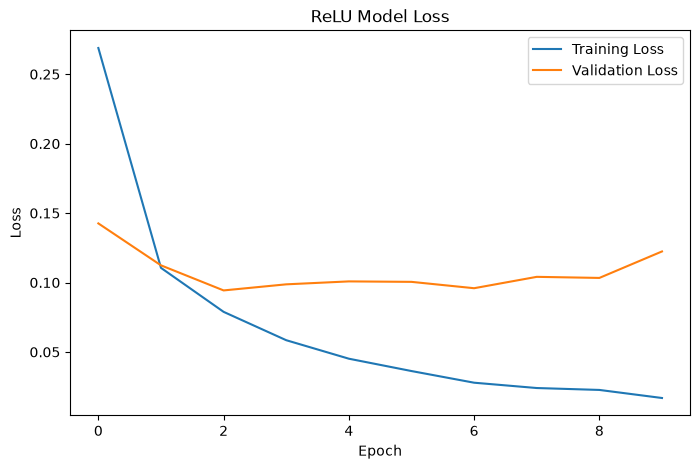

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history_relu.history["loss"], label="Training Loss")
plt.plot(history_relu.history["val_loss"], label="Validation Loss")

plt.title("ReLU Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Plot Accuracy sigmoid

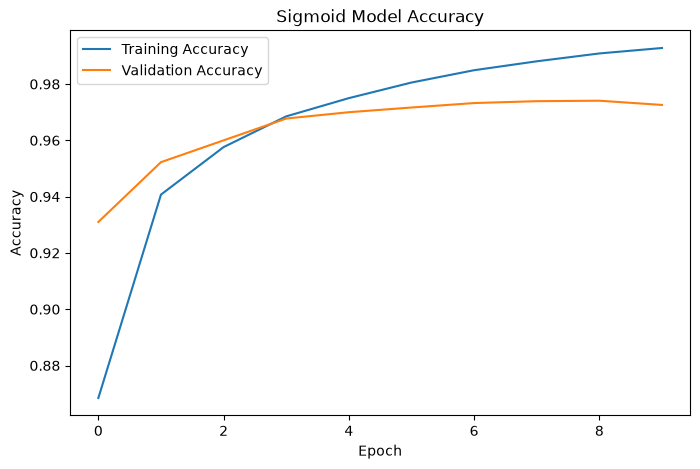

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history_sigmoid.history["accuracy"], label="Training Accuracy")
plt.plot(history_sigmoid.history["val_accuracy"], label="Validation Accuracy")

plt.title("Sigmoid Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## plot loss sigmoid

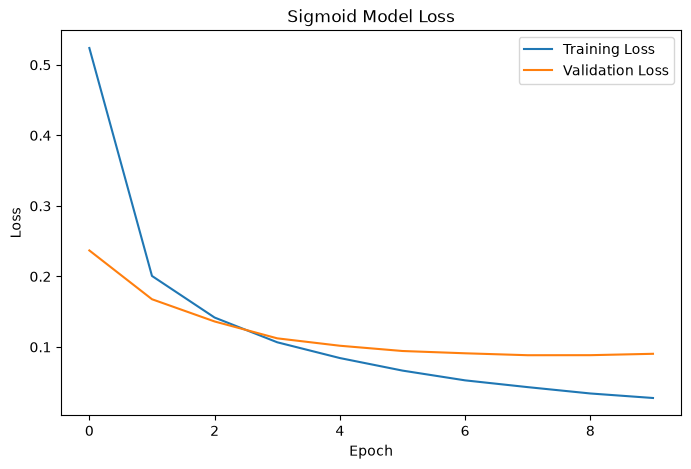

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history_sigmoid.history["loss"], label="Training Loss")
plt.plot(history_sigmoid.history["val_loss"], label="Validation Loss")

plt.title("Sigmoid Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## compare results

In [20]:
print("ReLU Accuracy :", relu_accuracy)
print("Sigmoid Accuracy :", sigmoid_accuracy)

print("ReLU Loss :", relu_loss)
print("Sigmoid Loss :", sigmoid_loss)


ReLU Accuracy : 0.9754999876022339
Sigmoid Accuracy : 0.9754999876022339
ReLU Loss : 0.10058750212192535
Sigmoid Loss : 0.08037586510181427


## predict kmage

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted: 7
Actual: 7


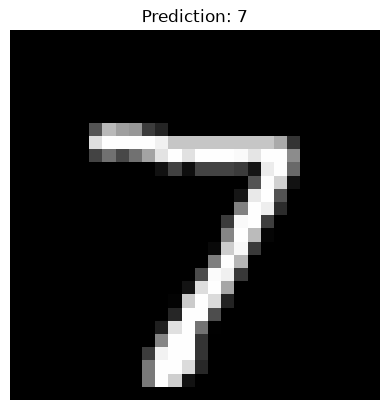

In [22]:
prediction = relu_model.predict(X_test)

predicted_label = np.argmax(prediction[0])
true_label = np.argmax(y_test[0])

print("Predicted:", predicted_label)
print("Actual:", true_label)

plt.imshow(X_test[0].reshape(28,28), cmap="gray")
plt.title("Prediction: {}".format(predicted_label))
plt.axis("off")
plt.show()
